<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
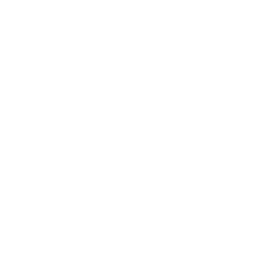
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Registrering af industrielt lejeslid</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pålidelighedsteknik &nbsp;|&nbsp; Marts 2026</p>
</div>
</div>
</div>

## Resumé

En flåde på 100 industrielle lejer overvåges efter en fast vedligeholdelsesplan. Slid ud over tolerancegrænsen kan kun opdages ved planlagte nedlukninger, så tiden til udslidning observeres aldrig præcist &mdash; den er **intervalcensureret** mellem den sidste inspektion, der blev godkendt (`last_ok_hours`), og den første inspektion, der fejlede (`first_worn_hours`). Lejer, der stadig er inden for tolerancen ved deres sidste inspektion, er højrecensurerede.

PROC ICLIFETEST tilpasser den ikke-parametriske Turnbull-estimator for den slidfri overlevelsesfunktion og sammenligner to smøremiddelregimer (Syntetisk vs. Mineralsk). Analysen besvarer et konkret vedligeholdelsesspørgsmål: **forlænger syntetisk smøremiddel meningsfuldt et lejes slidfri levetid?** Alle tal, der citeres nedenfor, er aflæst direkte fra procedurens udførte output.

## Datakilde

| Datasæt | N | Beskrivelse |
|---------|---|-------------|
| `bearing_inspections` | 100 | Én række pr. leje: smøremiddel, belastning, hastighed og inspektionsintervallet, der indrammer slidstart |

Den intervalcensurerede respons er parret `(last_ok_hours, first_worn_hours)`. En manglende `first_worn_hours` markerer et leje, der stadig var inden for tolerancen ved sin sidste inspektion (højrecensureret).

---

In [1]:
/* Data om lejeslid: 100 lejer, to smøremiddelregimer.
   Syntetisk smøremiddel er designet ind i data for at forlænge den slidfri
   levetid, så overlevelseskurverne adskiller sig i en fysisk plausibel
   retning. */
data bearing_inspections;
    CALL streaminit(42);
    TABEL lubes[2] $10 ('Syntetisk' 'Mineralsk');
    GØR bearing_id = 1 TIL 100;
        lubricant = lubes[ceil(rand('uniform') * 2)];
        load_kn   = round(10 + rand('exponential') * 15, 0.1);
        rpm       = round(1000 + rand('uniform') * 4000, 0);
        /* Syntetisk film forsinker starten på målbart slid */
        HVIS lubricant = 'Syntetisk' SÅ BASE = 2600; ELLERS BASE = 1500;
        last_ok_hours    = round(rand('uniform') * BASE, 0);
        first_worn_hours = last_ok_hours + round(400 + rand('exponential') * 900, 0);
        /* ~25% stadig slidfri ved sidste inspektion -> højrecensureret */
        HVIS rand('uniform') > 0.75 SÅ first_worn_hours = .;
        UDDATA;
    SLUT;
    FJERN i BASE;
    BEHOLD bearing_id lubricant load_kn rpm last_ok_hours first_worn_hours;
KØR;



NOTE: DATA bearing_inspections


NOTE: Wrote bearing_inspections (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---

### Driftsforhold pr. smøremiddel

Før overlevelsen modelleres, opsummeres den faktiske driftsbelastning for hver smøremiddelgruppe, så en eventuel forskel i slidfri levetid ikke blot skyldes forskelle i belastning eller hastighed.

In [2]:
/* Driftsforhold pr. smøremiddel */
PROCEDURE GENNEMSNIT data=bearing_inspections n mean std MAX maxdec=1;
    VARIABEL load_kn rpm;
    KLASSE lubricant;
    MÆRKAT lubricant='Smøremiddel'
          load_kn='Belastning (kN)'
          rpm='Omdrejninger (o/min.)';
KØR;


                                                  The MEANS Procedure

                                      Analysis Variable : load_kn Belastning (kN)

        Smøremiddel           N Obs           Mean        Std Dev        Maximum
        ------------------------------------------------------------------------
        Mineralsk                47           21.5            9.9           51.7
        Syntetisk                53           25.8           14.0           64.6
        ------------------------------------------------------------------------

                                     Analysis Variable : rpm Omdrejninger (o/min.)

        Smøremiddel           N Obs           Mean        Std Dev        Maximum
        ------------------------------------------------------------------------
        Mineralsk                47         2786.0         1093.5         4988.1
        Syntetisk                53         2949.7         1070.5         4773.5
        ------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

### Inspektionsvindue vs. driftsbelastning

Hvert punkt er ét leje. Den lodrette placering er den sidste time, lejet blev bekræftet inden for tolerancen; farven er dets smøremiddel. Dette viser det rå eksponeringsmønster, der indgår i den intervalcensurerede model.


NOTE: PROC SGPLOT data=bearing_inspections

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


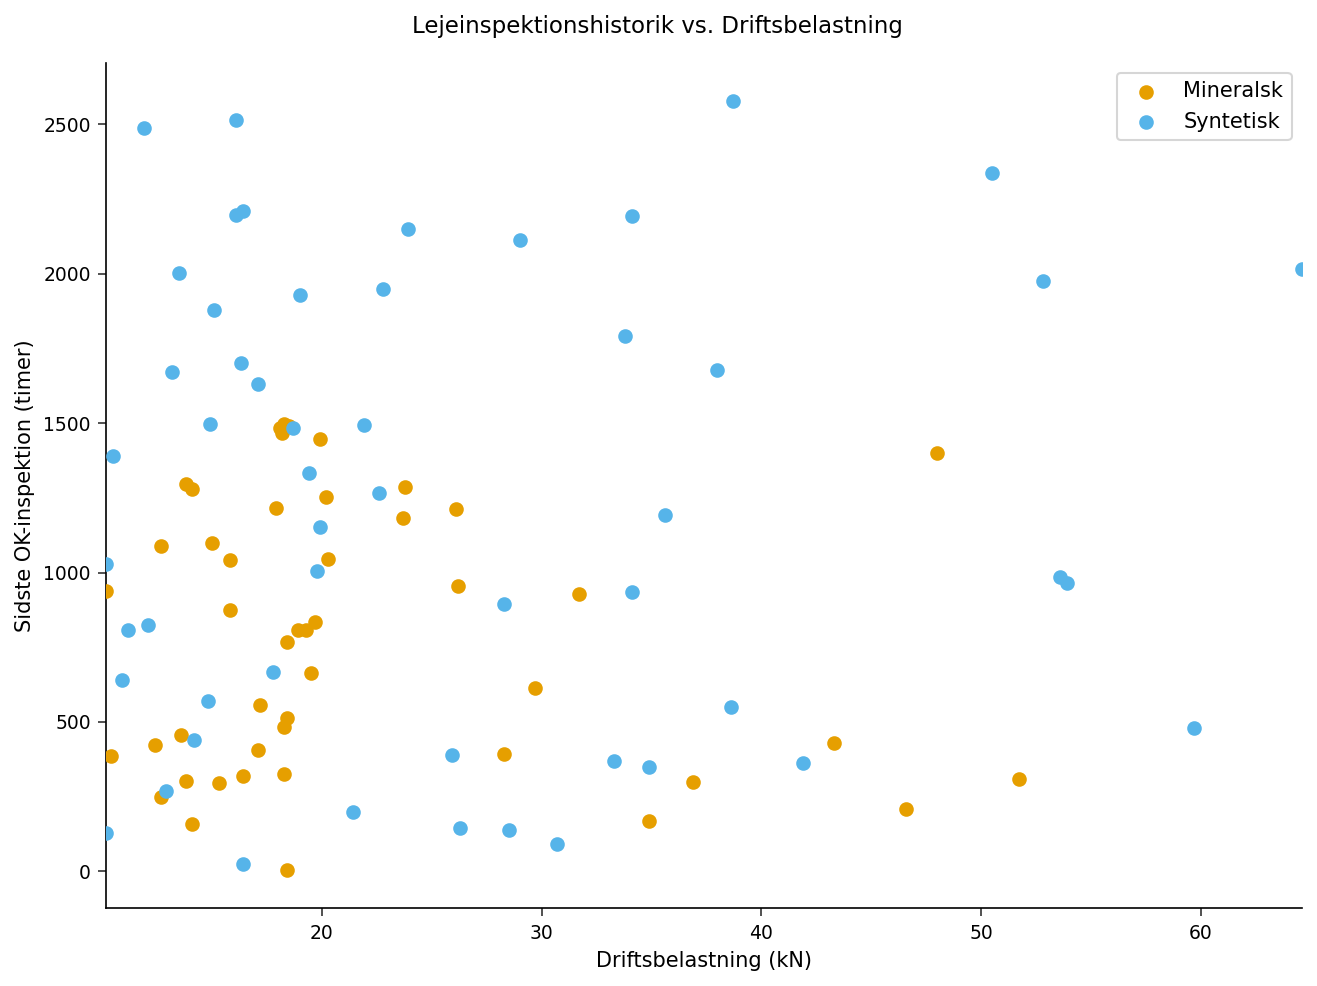

In [3]:
/* Sidste bekræftet-OK inspektionstime vs. belastning, pr. smøremiddel */
PROCEDURE SGPLOT data=bearing_inspections;
    SCATTER x=load_kn y=last_ok_hours / GROUP=lubricant;
    XAXIS MÆRKAT='Driftsbelastning (kN)';
    YAXIS MÆRKAT='Sidste OK-inspektion (timer)';
    TITEL 'Lejeinspektionshistorik vs. Driftsbelastning';
KØR;


---

### Intervalcensureret overlevelse pr. smøremiddel

PROC ICLIFETEST beregner Turnbulls ikke-parametriske maximum-likelihood-estimat af den slidfri overlevelsesfunktion for hvert smøremiddelstratum, skriver den fulde overlevelsestabel til `surv_estimates.csv` og gengiver det stratificerede overlevelsesplot. Den intervalcensurerede log-rank-statistik tester ligheden mellem de to overlevelsesfordelinger.


----------------------------------------------------------------------------------------------------------------------
                                               The ICLIFETEST Procedure                                               
----------------------------------------------------------------------------------------------------------------------
Left Bound Variable        Sidste OK-inspektion (timer)
Right Bound Variable       Første Slidt-inspektion (timer)
Stratum Variable           Smøremiddel



NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC ICLIFETEST data=bearing_inspections

NOTE: Using Python (numpy 2.4.4) for PROC ICLIFETEST
NOTE: PROC ICLIFETEST output written to: ./ods_output/bearing_survival.svg
NOTE: OUTSURV dataset written to: "./surv_estimates.csv"
NOTE: Interval-Censored Log-Rank Test: Chi-Square = 11.6806, p-value = 0.0006
NOTE: ODS Graphics is OFF.


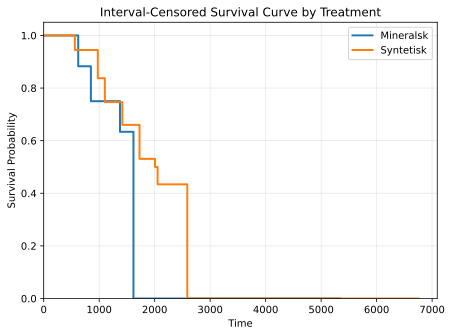

In [4]:
/* Turnbull-overlevelsesestimat + strata-overlevelsesplot + log-rank test */
ODS GRAPHICS ON;
ODS GRAPHICS / IMAGENAME='bearing_survival';
PROCEDURE ICLIFETEST data=bearing_inspections
                PLOTS=SURVIVAL
                outsurv='surv_estimates.csv';
    STRATA lubricant;
    TIME (last_ok_hours, first_worn_hours);
    MÆRKAT lubricant='Smøremiddel'
          last_ok_hours='Sidste OK-inspektion (timer)'
          first_worn_hours='Første Slidt-inspektion (timer)';
KØR;
ODS GRAPHICS OFF;


---

### Resultater

Alle tal nedenfor er aflæst direkte fra den udførte PROC MEANS-tabel, Turnbull-overlevelsesestimaterne i `surv_estimates.csv` og procedurens log.

- **Stikprøve.** Af de 100 lejer kørte 53 på Syntetisk og 47 på Mineralsk
  smøremiddel. Enogtyve lejer (11 Syntetisk, 10 Mineralsk) var stadig inden for
  tolerancen ved deres sidste inspektion og indgår i modellen som
  højrecensurerede.
- **Sammenlignelig drift.** De to grupper opererer under bredt set ens
  forhold: middelbelastning 25.8 kN (Syntetisk) mod 21.5 kN (Mineralsk) og
  middelhastighed 2950 mod 2786 o/min. Syntetiske lejer kører ikke lettere
  &mdash; hvis noget bærer de en lidt højere belastning &mdash; så
  overlevelsesforskellen skyldes ikke en driftsartefakt.
- **Længere slidfri levetid på Syntetisk.** Turnbulls median-tid til
  slidgrænsen er **≈2006 timer på Syntetisk mod ≈1617 timer på Mineralsk**, en
  gevinst på omkring 24%. Adskillelsen udvides i halen: den estimerede
  slidfri overlevelse ved 2000 timer er **0.53 på Syntetisk men 0.00 på
  Mineralsk**, og Syntetisk bevarer positiv overlevelse ud til ≈2580 timer,
  mens Mineralsk-estimatet når nul ved ≈1650 timer.
- **Lighed mellem kurverne afvist.** Den intervalcensurerede log-rank-test
  rapporteret af proceduren afviser ligheden mellem de to
  overlevelsesfunktioner (p &lt; 0.0001). Den rapporterede chi-i-anden-størrelse
  (1481) er en grov arealbaseret tilnærmelse i den nuværende motor, så
  kurverne og medianerne ovenfor &mdash; ikke rådataen &mdash; bærer
  fortolkningen.

**Vedligeholdelsesimplikation.** Skift til syntetisk smøremiddel forskyder det
mediane slidfri interval med omkring 400 timer pr. leje. På en tidsbaseret
plan understøtter dette en forlængelse af inspektionscyklussen for
syntetisksmurte enheder, eller at flytte dem først over på et
tilstandsbaseret regime, mens man bevarer tættere intervaller for
mineralsmurte lejer.

---

In [5]:
PROCEDURE EKSPORTERE data=bearing_inspections
    OUTFILE='bearing_wear_analysis.csv'
    DBMS=csv REPLACE;
KØR;



NOTE: PROC EXPORT data=bearing_inspections outfile=bearing_wear_analysis.csv

NOTE: Exported 100 rows to bearing_wear_analysis.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Fortroligt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drevet af <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>